# 05 Detecting Deviations from Expected Cycling Counts

This notebook identifies deviations from expected cycling traffic during the prediction period from May 2025 to April 2026.

The expected counts were computed in the previous notebook using the final negative binomial model. In this notebook, observed counts are compared with expected counts. A 2-hour interval is classified as a deviation only when the difference is both large in absolute terms (larger than 25) and large relative to the expected count (larger than 0.75).

### Packages and path

In [ ]:
import pandas as pd
import numpy as np

from pathlib import Path
import nbformat

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.express as plotly



project_folder = Path("..")

processed_folder = project_folder / "data" / "processed"
diagnostics_folder = project_folder / "data" / "diagnostics"

### Loading model development data

In [2]:
model_development_data = pd.read_csv(
    processed_folder / "model_development_data.csv"
)

model_development_data["date"] = pd.to_datetime(
    model_development_data["date"],
    errors="coerce"
)

model_development_data.info()
model_development_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 3361867 entries, 0 to 3361866
Data columns (total 28 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   site_id                       int64         
 1   direction                     str           
 2   year                          int64         
 3   date                          datetime64[us]
 4   month                         int64         
 5   weekday                       str           
 6   hour_bin                      int64         
 7   count                         float64       
 8   observed_intervals            int64         
 9   total_intervals               int64         
 10  missing_intervals             int64         
 11  missing_share                 float64       
 12  expected_intervals_for_row    int64         
 13  count_rescaled                int64         
 14  rescaled                      int64         
 15  longitude                     float64      

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,...,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,fuel_price_petrol_95_rounded
0,1,IN,2022,2022-05-01,5,Sunday,0,13.0,8,8,...,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,1.8
1,1,IN,2022,2022-05-01,5,Sunday,2,2.0,8,8,...,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,1.8
2,1,IN,2022,2022-05-01,5,Sunday,4,1.0,8,8,...,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,1.8
3,1,IN,2022,2022-05-01,5,Sunday,6,6.0,8,8,...,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,1.8
4,1,IN,2022,2022-05-01,5,Sunday,8,26.0,8,8,...,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,1.8


### Loading expected count data

In [3]:
expected_counts = pd.read_csv(
    processed_folder / "expected_counts.csv"
)

expected_counts["date"] = pd.to_datetime(
    expected_counts["date"],
    errors="coerce"
)

expected_counts.info()
expected_counts.head()

<class 'pandas.DataFrame'>
RangeIndex: 1177575 entries, 0 to 1177574
Data columns (total 46 columns):
 #   Column                        Non-Null Count    Dtype         
---  ------                        --------------    -----         
 0   site_id                       1177575 non-null  int64         
 1   direction                     1177575 non-null  str           
 2   year                          1177575 non-null  int64         
 3   date                          1177575 non-null  datetime64[us]
 4   month                         1177575 non-null  int64         
 5   weekday                       1177575 non-null  str           
 6   hour_bin                      1177575 non-null  int64         
 7   count                         1177575 non-null  float64       
 8   observed_intervals            1177575 non-null  int64         
 9   total_intervals               1177575 non-null  int64         
 10  missing_intervals             1177575 non-null  int64         
 11  missing_s

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,...,precipitation_category,is_strike,is_outdoor_music,outdoor_music_event_type,is_indoor_music,indoor_music_event_type,is_sport_event,sport_event_type,fuel_price_petrol_95_rounded,expected_count
0,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,...,dry,0,0,No event,0,No event,0,No event,1.5,1.570605
1,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,...,dry,0,0,No event,0,No event,0,No event,1.5,0.834287
2,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,...,dry,0,0,No event,0,No event,0,No event,1.5,6.207436
3,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,...,dry,0,0,No event,0,No event,0,No event,1.5,36.715265
4,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,...,dry,0,0,No event,0,No event,0,No event,1.5,41.707795


Basic checks

In [4]:
print("Rows:", expected_counts.shape[0])
print("Columns:", expected_counts.shape[1])

print("Date range:")
print(expected_counts["date"].min(), "to", expected_counts["date"].max())

print("Missing observed counts:", expected_counts["count_rescaled"].isna().sum())
print("Missing expected counts:", expected_counts["expected_count"].isna().sum())

print("Minimum expected count:", expected_counts["expected_count"].min())
print("Maximum expected count:", expected_counts["expected_count"].max())

Rows: 1177575
Columns: 46
Date range:
2025-05-01 00:00:00 to 2026-04-30 00:00:00
Missing observed counts: 0
Missing expected counts: 0
Minimum expected count: 0.0268975028755632
Maximum expected count: 996.2876399297444


In [5]:
event_factors = [
    "is_strike",
    "is_outdoor_music",
    "is_indoor_music",
    "is_sport_event",
]

for col in event_factors:
    print("\n", col)
    print(expected_counts[col].value_counts(dropna=False))
    print("Unique values:", expected_counts[col].unique()[:10])
    print("Dtype:", expected_counts[col].dtype)


 is_strike
is_strike
0    1129175
1      48400
Name: count, dtype: int64
Unique values: [0 1]
Dtype: int64

 is_outdoor_music
is_outdoor_music
0    1175439
1       2136
Name: count, dtype: int64
Unique values: [0 1]
Dtype: int64

 is_indoor_music
is_indoor_music
0    1177287
1        288
Name: count, dtype: int64
Unique values: [0 1]
Dtype: int64

 is_sport_event
is_sport_event
0    1175971
1       1604
Name: count, dtype: int64
Unique values: [0 1]
Dtype: int64


## Defining Deviations

### Defining reference counts

In [6]:
reference_variables = [
    "site_id",
    "direction",
    "month",
    "weekday",
    "hour_bin",
]

reference_counts = (
    model_development_data
    .groupby(reference_variables)
    .size()
    .reset_index(name="reference_n")
)

deviation_data = expected_counts.merge(
    reference_counts,
    on=reference_variables,
    how="left"
)

print("Missing reference_n:", deviation_data["reference_n"].isna().sum())

deviation_data["reference_n"] = (
    deviation_data["reference_n"]
    .fillna(0)
    .astype(int)
)

Missing reference_n: 0


In [7]:
print("Share with reference_n >= 10:")
print((deviation_data["reference_n"] >= 10).mean())

deviation_data["reference_n"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50]
)

Share with reference_n >= 10:
0.8057210793367726


count    1.177575e+06
mean     1.199000e+01
std      1.967225e+00
min      4.000000e+00
1%       8.000000e+00
5%       8.000000e+00
10%      9.000000e+00
25%      1.200000e+01
50%      1.300000e+01
max      1.400000e+01
Name: reference_n, dtype: float64

### Computing differences

In [8]:
deviation_data["difference"] = (
    deviation_data["count_rescaled"] - deviation_data["expected_count"]
)

deviation_data["relative_difference"] = (
    deviation_data["difference"] / deviation_data["expected_count"]
)

### Defining deviations

In [9]:
deviation_data["is_deviation"] = (
    (deviation_data["reference_n"] >= 10) &
    (deviation_data["difference"].abs() > 25) &
    (deviation_data["relative_difference"].abs() > 0.75)
).astype(int)

In [10]:
deviation_data["deviation_direction"] = "No deviation"

deviation_data.loc[
    (deviation_data["is_deviation"] == 1) &
    (deviation_data["difference"] > 0),
    "deviation_direction"
] = "Higher than expected"

deviation_data.loc[
    (deviation_data["is_deviation"] == 1) &
    (deviation_data["difference"] < 0),
    "deviation_direction"
] = "Lower than expected"

In [11]:
deviation_data.head(10)

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,...,indoor_music_event_type,is_sport_event,sport_event_type,fuel_price_petrol_95_rounded,expected_count,reference_n,difference,relative_difference,is_deviation,deviation_direction
0,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,...,No event,0,No event,1.5,1.570605,13,-0.570605,-0.363303,0,No deviation
1,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,...,No event,0,No event,1.5,0.834287,13,0.165713,0.198629,0,No deviation
2,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,...,No event,0,No event,1.5,6.207436,13,-3.207436,-0.516709,0,No deviation
3,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,...,No event,0,No event,1.5,36.715265,13,-33.715265,-0.918290,1,Lower than expected
4,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,...,No event,0,No event,1.5,41.707795,13,1.292205,0.030982,0,No deviation
5,1,IN,2025,2025-05-01,5,Thursday,10,28.0,8,8,...,No event,0,No event,1.5,27.603782,13,0.396218,0.014354,0,No deviation
6,1,IN,2025,2025-05-01,5,Thursday,12,19.0,8,8,...,No event,0,No event,1.5,36.223882,13,-17.223882,-0.475484,0,No deviation
7,1,IN,2025,2025-05-01,5,Thursday,14,45.0,8,8,...,No event,0,No event,1.5,48.032402,13,-3.032402,-0.063132,0,No deviation
8,1,IN,2025,2025-05-01,5,Thursday,16,26.0,8,8,...,No event,0,No event,1.5,60.624957,13,-34.624957,-0.571134,0,No deviation
9,1,IN,2025,2025-05-01,5,Thursday,18,19.0,8,8,...,No event,0,No event,1.5,26.469498,13,-7.469498,-0.282193,0,No deviation


# Analyzing Deviations: EDA

### Overall summary

In [12]:
overall_summary = pd.DataFrame({
    "total_observations": [deviation_data.shape[0]],
    "total_deviations": [deviation_data["is_deviation"].sum()],
    "share_deviations": [deviation_data["is_deviation"].mean()],
    "higher_than_expected": [
        (deviation_data["deviation_direction"] == "Higher than expected").sum()
    ],
    "lower_than_expected": [
        (deviation_data["deviation_direction"] == "Lower than expected").sum()
    ],
})

overall_summary

,total_observations,total_deviations,share_deviations,higher_than_expected,lower_than_expected
0,1177575,129793,0.110221,76613,53180


### Size of the deviations

In [13]:
deviation_data.loc[
    deviation_data["is_deviation"] == 1,
    "difference"
].describe()

count    129793.000000
mean         23.122037
std          77.008641
min        -374.538511
25%         -34.760885
50%          30.485943
75%          57.817373
max        1889.474262
Name: difference, dtype: float64

In [14]:
deviation_data.loc[
    deviation_data["is_deviation"] == 1,
    "difference"
].groupby(deviation_data.loc[deviation_data["is_deviation"] == 1, "deviation_direction"]).describe()

,count,mean,std,min,25%,50%,75%,max
deviation_direction,,,,,,,,
Higher than expected,76613.0,71.366296,62.880889,25.001955,34.818373,50.578283,83.075470,1889.474262
Lower than expected,53180.0,-46.380360,24.367882,-374.538511,-53.402717,-38.753790,-30.597049,-25.001969


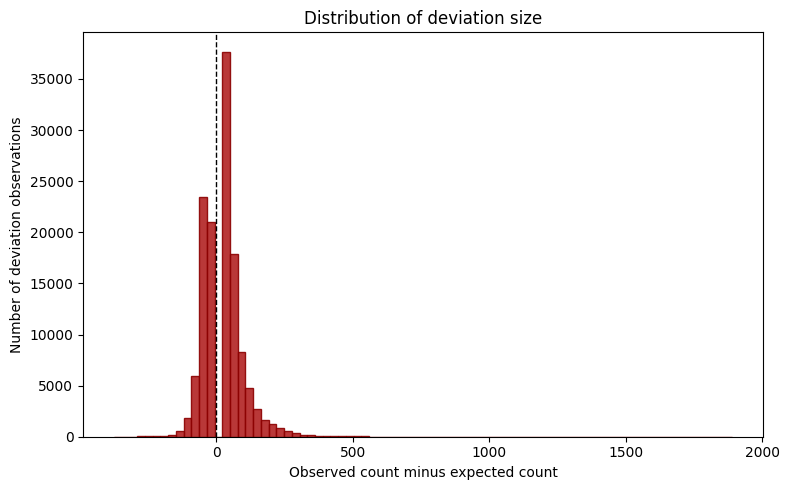

In [69]:
deviation_rows = deviation_data["is_deviation"] == 1

plt.figure(figsize=(8, 5))

plt.hist(
    deviation_data.loc[deviation_rows, "difference"],
    bins=80,
    color="firebrick",
    edgecolor="darkred",
    alpha=0.90
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Observed count minus expected count")
plt.ylabel("Number of deviation observations")
plt.title("Distribution of deviation size")

plt.tight_layout()
plt.show()

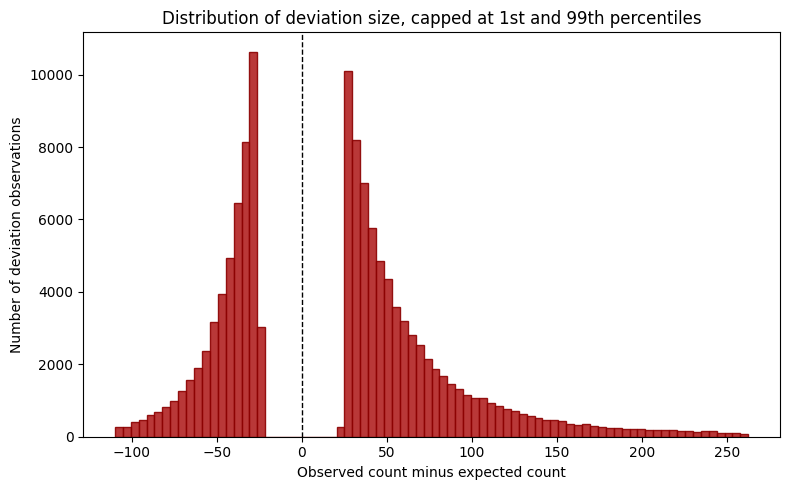

In [89]:

deviation_differences = deviation_data.loc[
    deviation_rows,
    "difference"
]

lower_limit = deviation_differences.quantile(0.01)
upper_limit = deviation_differences.quantile(0.99)

deviation_differences_capped = deviation_differences[
    (deviation_differences >= lower_limit) &
    (deviation_differences <= upper_limit)
]

plt.figure(figsize=(8, 5))

plt.hist(
    deviation_differences_capped,
    bins=80,
    color="firebrick",
    edgecolor="darkred",
    alpha=0.90
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Observed count minus expected count")
plt.ylabel("Number of deviation observations")
plt.title("Distribution of deviation size, capped at 1st and 99th percentiles")

plt.tight_layout()
plt.show()

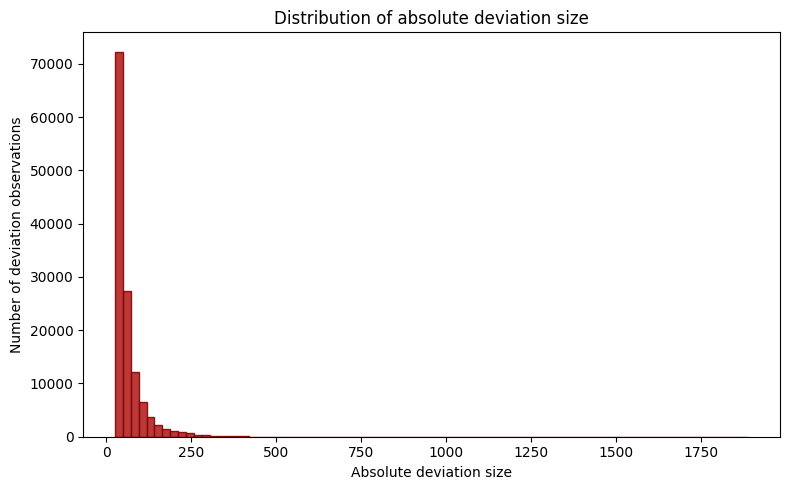

In [74]:
plt.figure(figsize=(8, 5))

plt.hist(
    deviation_data.loc[deviation_rows, "difference"].abs(),
    bins=80,
    color="firebrick",
    edgecolor="darkred",
    alpha=0.90
)

plt.xlabel("Absolute deviation size")
plt.ylabel("Number of deviation observations")
plt.title("Distribution of absolute deviation size")

plt.tight_layout()
plt.show()

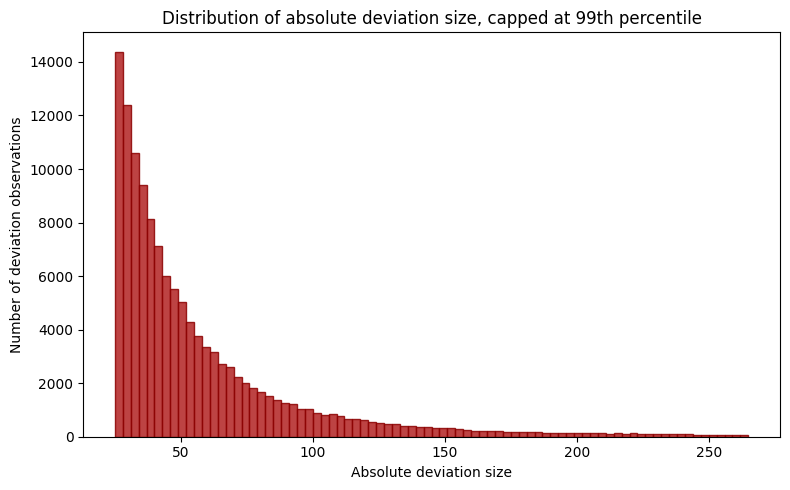

In [75]:
deviation_size_abs = deviation_data.loc[
    deviation_rows,
    "difference"
].abs()

upper_limit = deviation_size_abs.quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    deviation_size_abs[deviation_size_abs <= upper_limit],
    bins=80,
    color="firebrick",
    edgecolor="darkred",
    alpha=0.85
)

plt.xlabel("Absolute deviation size")
plt.ylabel("Number of deviation observations")
plt.title("Distribution of absolute deviation size, capped at 99th percentile")

plt.tight_layout()
plt.show()

### Largest deviations

In [19]:
deviation_data.loc[
    deviation_data["is_deviation"] == 1
].sort_values(
    "difference",
    ascending=False
)[
    [
        "site_id",
        "site_name",
        "date",
        "weekday",
        "hour_bin",
        "direction",
        "count_rescaled",
        "expected_count",
        "difference",
        "relative_difference",
        "precipitation_category",
        "is_strike",
        "is_outdoor_music",
        "is_indoor_music",
        "is_sport_event",
    ]
].head(20)

,site_id,site_name,date,weekday,hour_bin,direction,count_rescaled,expected_count,difference,relative_difference,precipitation_category,is_strike,is_outdoor_music,is_indoor_music,is_sport_event
1150387,138,Hasselt-Kempische brug,2025-08-14,Thursday,18,OUT,2028,138.525738,1889.474262,13.639879,dry,0,0,0,0
896249,107,leuven totem,2026-04-19,Sunday,14,IN,1993,321.916248,1671.083752,5.191051,light_precipitation,0,0,0,0
585996,69,Leuven teller 1,2026-04-19,Sunday,16,IN,1695,139.545610,1555.454390,11.146566,dry,0,0,0,0
1150388,138,Hasselt-Kempische brug,2025-08-14,Thursday,20,OUT,1615,70.777400,1544.222600,21.818018,dry,0,0,0,0
900629,107,leuven totem,2026-04-19,Sunday,16,OUT,1663,204.700924,1458.299076,7.124047,light_precipitation,0,0,0,0
78328,10,Aalst 2,2025-05-18,Sunday,8,IN,1472,16.029526,1455.970474,90.830537,dry,0,0,0,0
157150,19,Aalst 1,2025-05-18,Sunday,8,IN,1478,29.853200,1448.146800,48.508930,dry,0,0,0,0
715772,84,Roeselare totem,2025-08-15,Friday,12,OUT,1476,36.578405,1439.421595,39.351677,dry,0,0,0,0
539528,64,Nieuwpoort teller 1,2025-08-15,Friday,10,IN,1451,129.527545,1321.472455,10.202250,dry,0,0,0,0
596600,70,Kampenhout teller 1,2025-09-20,Saturday,12,OUT,1292,30.885087,1261.114913,40.832487,light_precipitation,0,0,0,0


In [20]:
deviation_data.loc[
    deviation_data["is_deviation"] == 1
].sort_values(
    "difference",
    ascending=True
)[
    [
        "site_id",
        "site_name",
        "date",
        "weekday",
        "hour_bin",
        "direction",
        "count_rescaled",
        "expected_count",
        "difference",
        "relative_difference",
        "precipitation_category",
        "is_strike",
        "is_outdoor_music",
        "is_indoor_music",
        "is_sport_event",
    ]
].head(20)

,site_id,site_name,date,weekday,hour_bin,direction,count_rescaled,expected_count,difference,relative_difference,precipitation_category,is_strike,is_outdoor_music,is_indoor_music,is_sport_event
893282,107,leuven totem,2025-08-15,Friday,6,IN,63,437.538511,-374.538511,-0.856013,dry,0,0,0,0
892982,107,leuven totem,2025-07-21,Monday,6,IN,36,405.931230,-369.931230,-0.911315,dry,0,0,0,0
1146175,138,Hasselt-Kempische brug,2025-08-28,Thursday,16,IN,68,406.448308,-338.448308,-0.832697,light_precipitation,0,0,0,0
583033,69,Leuven teller 1,2025-08-15,Friday,16,IN,64,394.477485,-330.477485,-0.837760,dry,0,0,0,0
582923,69,Leuven teller 1,2025-08-06,Wednesday,12,IN,86,409.789971,-323.789971,-0.790136,dry,0,0,0,0
1146091,138,Hasselt-Kempische brug,2025-08-21,Thursday,16,IN,83,406.448308,-323.448308,-0.795792,dry,0,0,0,0
1145923,138,Hasselt-Kempische brug,2025-08-07,Thursday,16,IN,88,406.448308,-318.448308,-0.783490,dry,0,0,0,0
582864,69,Leuven teller 1,2025-08-01,Friday,14,IN,82,400.382697,-318.382697,-0.795196,light_precipitation,0,0,0,0
583091,69,Leuven teller 1,2025-08-20,Wednesday,12,IN,99,409.789971,-310.789971,-0.758413,dry,0,0,0,0
897661,107,leuven totem,2025-08-15,Friday,6,OUT,33,340.977782,-307.977782,-0.903220,dry,0,0,0,0


### Deviations over time

In [21]:
monthly_deviation_summary = (
    deviation_data
    .groupby("month")
    .agg(
        observations=("is_deviation", "size"),
        deviations=("is_deviation", "sum"),
    )
    .reset_index()
)

monthly_deviation_summary["deviation_share"] = (
    monthly_deviation_summary["deviations"]
    / monthly_deviation_summary["observations"]
)

monthly_deviation_summary

,month,observations,deviations,deviation_share
0,1,99968,8079,0.080816
1,2,89576,8346,0.093172
2,3,100114,14639,0.146223
3,4,97084,15724,0.161963
4,5,100586,7396,0.073529
5,6,96288,8549,0.088786
6,7,99502,11094,0.111495
7,8,99688,12404,0.124428
8,9,97917,12281,0.125423
9,10,100510,12001,0.119401


In [22]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_deviation_summary = (
    deviation_data
    .groupby("weekday")
    .agg(
        observations=("is_deviation", "size"),
        deviations=("is_deviation", "sum"),
    )
    .reindex(weekday_order)
    .reset_index()
)

weekday_deviation_summary["deviation_share"] = (
    weekday_deviation_summary["deviations"]
    / weekday_deviation_summary["observations"]
)

weekday_deviation_summary

,weekday,observations,deviations,deviation_share
0,Monday,167848,19990,0.119096
1,Tuesday,167763,21408,0.127609
2,Wednesday,167741,23706,0.141325
3,Thursday,171006,21932,0.128253
4,Friday,167805,19534,0.116409
5,Saturday,167821,11653,0.069437
6,Sunday,167591,11570,0.069037


In [23]:
hour_deviation_summary = (
    deviation_data
    .groupby("hour_bin")
    .agg(
        observations=("is_deviation", "size"),
        deviations=("is_deviation", "sum"),
    )
    .reset_index()
)

hour_deviation_summary["deviation_share"] = (
    hour_deviation_summary["deviations"]
    / hour_deviation_summary["observations"]
)

hour_deviation_summary

,hour_bin,observations,deviations,deviation_share
0,0,98150,411,0.004187
1,2,97876,181,0.001849
2,4,98110,1011,0.010305
3,6,98156,16362,0.166694
4,8,98153,17803,0.181380
5,10,98160,13715,0.139721
6,12,98163,17618,0.179477
7,14,98164,20933,0.213245
8,16,98159,24068,0.245194
9,18,98162,11759,0.119792


In [24]:
hour_deviation_direction_summary = (
    deviation_data[deviation_data["is_deviation"] == 1]
    .pivot_table(
        index="hour_bin",
        columns="deviation_direction",
        values="site_id",
        aggfunc="size",
        fill_value=0
    )
)

hour_deviation_direction_summary

deviation_direction,Higher than expected,Lower than expected
hour_bin,,
0,410,1
2,180,1
4,811,200
6,9433,6929
8,10356,7447
10,7612,6103
12,9701,7917
14,11176,9757
16,13243,10825


In [76]:
hour_direction = (
    deviation_data
    .groupby(["hour_bin", "deviation_direction"])
    .size()
    .reset_index(name="count")
)

hour_direction = hour_direction[
    hour_direction["deviation_direction"] != "No deviation"
]

direction_colors = {
    "Higher than expected": "#b2182b" , 
    "Lower than expected": "#fdae61",   
}

fig = plotly.bar(
    hour_direction,
    x="hour_bin",
    y="count",
    color="deviation_direction",
    color_discrete_map=direction_colors,
    barmode="group",
    title="Deviation direction by time of day",
    labels={
        "hour_bin": "Start of 2-hour interval",
        "count": "Number of deviations",
        "deviation_direction": "Deviation direction",
    },
)

fig.update_layout(
    plot_bgcolor="#f2f2f2",
    paper_bgcolor="#f2f2f2",
    font=dict(color="#333333"),
    title=dict(x=0.02),
    legend_title_text="Deviation direction",
)

fig.update_xaxes(
    showgrid=False,
    tickmode="array",
    tickvals=sorted(hour_direction["hour_bin"].unique()),
)

fig.update_yaxes(
    gridcolor="white",
    zerolinecolor="white",
)

fig.show()

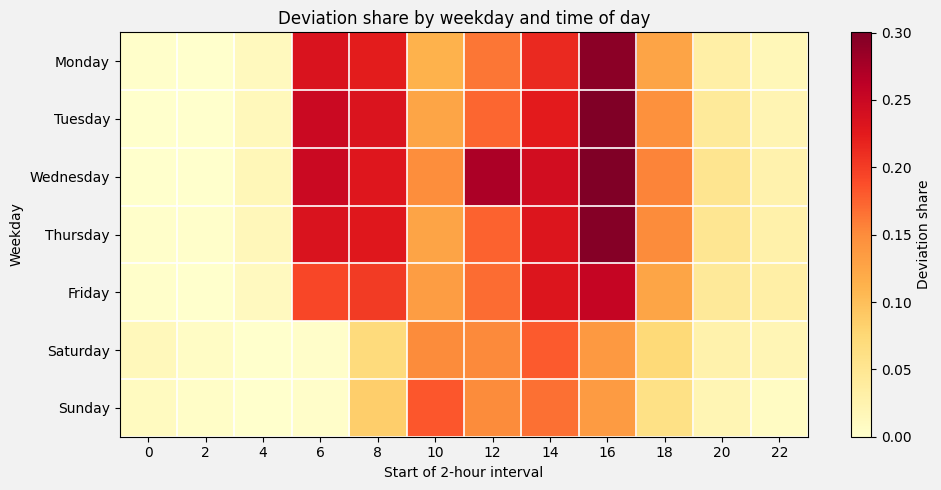

In [77]:
hour_weekday_summary = (
    deviation_data
    .groupby(["weekday", "hour_bin"])
    .agg(
        observations=("is_deviation", "size"),
        deviations=("is_deviation", "sum")
    )
    .reset_index()
)

hour_weekday_summary["deviation_share"] = (
    hour_weekday_summary["deviations"] /
    hour_weekday_summary["observations"]
)

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

heatmap_data = (
    hour_weekday_summary
    .pivot(index="weekday", columns="hour_bin", values="deviation_share")
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(10, 5))

fig.patch.set_facecolor("#f2f2f2")
ax.set_facecolor("#f2f2f2")

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap="YlOrRd"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Deviation share")

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xticks(np.arange(-0.5, len(heatmap_data.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heatmap_data.index), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_xlabel("Start of 2-hour interval")
ax.set_ylabel("Weekday")
ax.set_title("Deviation share by weekday and time of day")

plt.tight_layout()
plt.show()

### Deviations and sites

In [25]:
site_deviation_summary = (
    deviation_data
    .groupby(["site_id", "site_name", "municipality"])
    .agg(
        observations=("is_deviation", "size"),
        deviations=("is_deviation", "sum"),
        mean_difference=("difference", "mean"),
        mean_expected_count=("expected_count", "mean"),
        mean_observed_count=("count_rescaled", "mean"),
    )
    .reset_index()
)

site_deviation_summary["deviation_share"] = (
    site_deviation_summary["deviations"]
    / site_deviation_summary["observations"]
)

pd.set_option("display.max_rows", None)
site_deviation_summary

,site_id,site_name,municipality,observations,deviations,mean_difference,mean_expected_count,mean_observed_count,deviation_share
0,1,Machelen,Machelen,8758,146,-2.448212,18.978013,16.529801,0.016670
1,2,Brasschaat 2,Brasschaat,8758,2448,5.891082,32.107319,37.998401,0.279516
2,3,Brasschaat 1,Brasschaat,8728,3992,-3.842108,38.723867,34.881760,0.457379
3,4,Balen 1,Balen,8758,701,0.694441,8.208619,8.903060,0.080041
4,5,Balen 2,Balen,8758,767,-0.428322,9.455154,9.026833,0.087577
5,6,Evergem 2,Evergem,8086,1552,0.173699,15.500800,15.674499,0.191937
6,7,Evergem 1,Evergem,8758,2173,-0.443978,16.477890,16.033912,0.248116
7,8,Heist op den Berg 1,Heist-op-den-Berg,8758,2057,0.502199,16.804149,17.306348,0.234871
8,9,Heist op den Berg 2,Heist-op-den-Berg,8758,1758,0.344399,18.844228,19.188628,0.200731
9,10,Aalst 2,Aalst,8758,386,3.085623,12.967928,16.053551,0.044074


In [26]:
site_deviation_direction_summary = (
    deviation_data[deviation_data["is_deviation"] == 1]
    .pivot_table(
        index=["site_id", "site_name", "municipality"],
        columns="deviation_direction",
        values="date",
        aggfunc="size",
        fill_value=0
    )
    .reset_index()
)

pd.set_option("display.max_rows", None)
site_deviation_direction_summary

deviation_direction,site_id,site_name,municipality,Higher than expected,Lower than expected
0,1,Machelen,Machelen,75,71
1,2,Brasschaat 2,Brasschaat,1295,1153
2,3,Brasschaat 1,Brasschaat,1516,2476
3,4,Balen 1,Balen,570,131
4,5,Balen 2,Balen,488,279
5,6,Evergem 2,Evergem,702,850
6,7,Evergem 1,Evergem,823,1350
7,8,Heist op den Berg 1,Heist-op-den-Berg,860,1197
8,9,Heist op den Berg 2,Heist-op-den-Berg,770,988
9,10,Aalst 2,Aalst,377,9


In [58]:
site_deviation_summary["site_stability_category"] = pd.cut(
    site_deviation_summary["deviation_share"],
    bins=[0.00, 0.10, 0.20, 1.0],
    labels=["Stable", "Moderately unstable", "Highly unstable"]
)

site_deviation_summary["site_stability_category"].value_counts()

site_stability_category
Stable                 78
Moderately unstable    33
Highly unstable        25
Name: count, dtype: int64

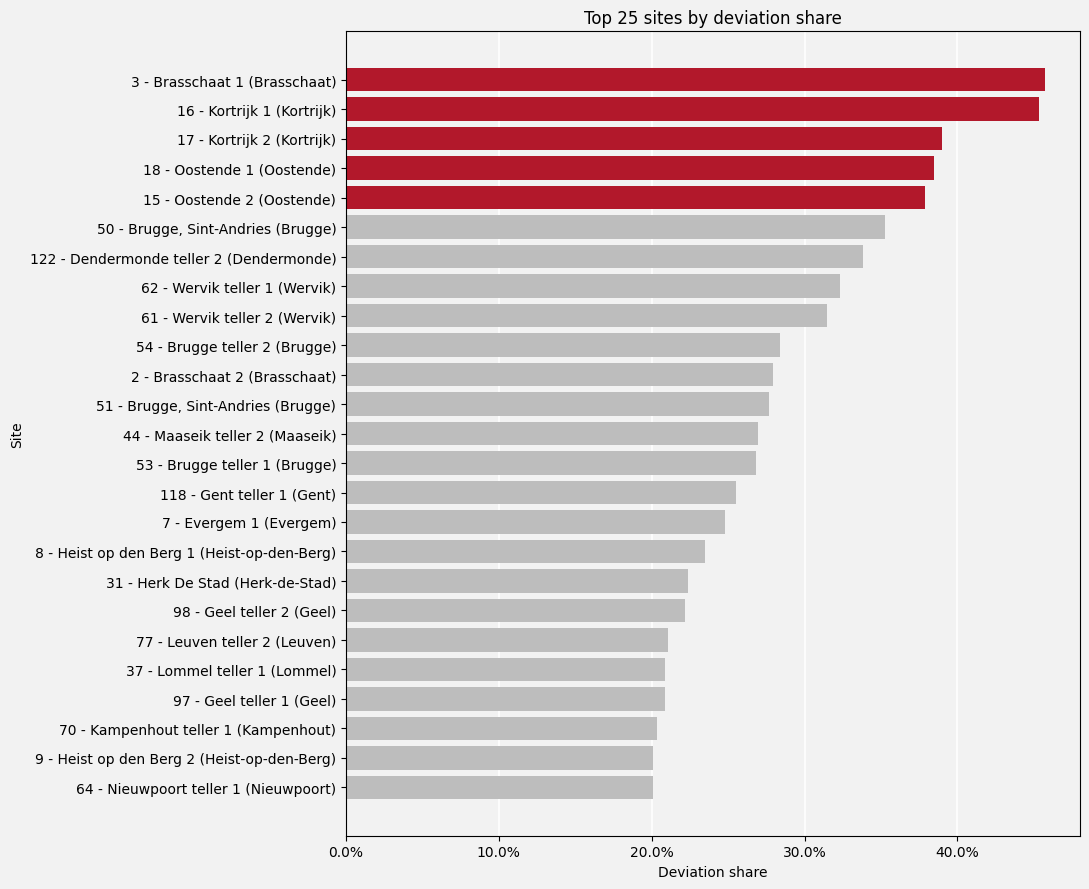

In [87]:
top_sites = (
    site_deviation_summary
    .sort_values("deviation_share", ascending=False)
    .head(25)
    .copy()
)

top_sites["site_label"] = (
    top_sites["site_id"].astype(str)
    + " - "
    + top_sites["site_name"]
    + " ("
    + top_sites["municipality"]
    + ")"
)

top_sites["rank"] = range(1, len(top_sites) + 1)

top_sites["bar_color"] = np.where(
    top_sites["rank"] <= 5,
    "#b2182b",   
    "#bdbdbd"    
)


top_sites = top_sites.sort_values("deviation_share", ascending=True)

fig, ax = plt.subplots(figsize=(11, 9))

fig.patch.set_facecolor("#f2f2f2")
ax.set_facecolor("#f2f2f2")

ax.barh(
    top_sites["site_label"],
    top_sites["deviation_share"],
    color=top_sites["bar_color"],
)

ax.set_xlabel("Deviation share")
ax.set_ylabel("Site")
ax.set_title("Top 25 sites by deviation share")

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="x", color="white", linewidth=1.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [27]:
site_map_data = (
    deviation_data
    .groupby(["site_id", "site_name", "municipality", "latitude", "longitude"])
    .agg(
        observations=("is_deviation", "size"),
        total_deviations=("is_deviation", "sum"),
        higher_deviations=("deviation_direction", lambda x: (x == "Higher than expected").sum()),
        lower_deviations=("deviation_direction", lambda x: (x == "Lower than expected").sum()),
        mean_difference=("difference", "mean"),
        mean_expected_count=("expected_count", "mean"),
        mean_observed_count=("count_rescaled", "mean"),
    )
    .reset_index()
)

site_map_data["total_deviation_share"] = (
    site_map_data["total_deviations"] / site_map_data["observations"]
)

site_map_data["higher_deviation_share"] = (
    site_map_data["higher_deviations"] / site_map_data["observations"]
)

site_map_data["lower_deviation_share"] = (
    site_map_data["lower_deviations"] / site_map_data["observations"]
)

In [28]:
def plot_deviation_map_plotly(data, share_column, count_column, title):
    fig = plotly.scatter_map(
        data,
        lat="latitude",
        lon="longitude",
        size=count_column,
        color=share_column,
        hover_name="site_name",
        hover_data={
            "site_id": True,
            "municipality": True,
            "observations": True,
            count_column: True,
            share_column: ":.2%",
            "mean_observed_count": ":.2f",
            "mean_expected_count": ":.2f",
            "mean_difference": ":.2f",
            "latitude": False,
            "longitude": False,
        },
        color_continuous_scale="YlOrRd",
        size_max=25,
        zoom=7,
        height=700,
        title=title,
    )

    fig.update_layout(
        map_style="carto-positron",
        margin={"r": 0, "t": 50, "l": 0, "b": 0},
    )

    fig.show()

In [29]:
plot_deviation_map_plotly(
    data=site_map_data,
    share_column="total_deviation_share",
    count_column="total_deviations",
    title="Total deviation share by counting site"
)

In [30]:
plot_deviation_map_plotly(
    data=site_map_data,
    share_column="higher_deviation_share",
    count_column="higher_deviations",
    title="Higher-than-expected deviation share by counting site"
)

In [31]:
plot_deviation_map_plotly(
    data=site_map_data,
    share_column="lower_deviation_share",
    count_column="lower_deviations",
    title="Lower-than-expected deviation share by counting site"
)

### Deviations and weather

In [32]:
precipitation_deviation_summary = (
    deviation_data
    .groupby("precipitation_category")
    .agg(
        observations=("is_deviation", "size"),
        deviations=("is_deviation", "sum"),
    )
    .reset_index()
)

precipitation_deviation_summary["deviation_share"] = (
    precipitation_deviation_summary["deviations"]
    / precipitation_deviation_summary["observations"]
)

precipitation_deviation_summary.sort_values("deviation_share", ascending=False)

,precipitation_category,observations,deviations,deviation_share
2,light_precipitation,181661,20465,0.112655
0,dry,937578,104808,0.111786
1,heavy_precipitation,4572,439,0.096019
3,moderate_precipitation,40432,3185,0.078774
4,snow,13332,896,0.067207


In [33]:
pd.crosstab(
    deviation_data["precipitation_category"],
    deviation_data["deviation_direction"],
    normalize="index"
)

deviation_direction,Higher than expected,Lower than expected,No deviation
precipitation_category,,,
dry,0.070825,0.040961,0.888214
heavy_precipitation,0.017935,0.078084,0.903981
light_precipitation,0.049108,0.063547,0.887345
moderate_precipitation,0.021963,0.056811,0.921226
snow,0.023852,0.043354,0.932793


In [34]:
deviation_data["temperature_bin"] = pd.cut(
    deviation_data["temperature_mean"],
    bins=[-20,-15,-10, 0, 5, 10, 15, 20, 25, 35, 40, 45],
)

temperature_deviation_summary = (
    deviation_data
    .groupby("temperature_bin", observed=True)
    .agg(
        observations=("is_deviation", "size"),
        deviations=("is_deviation", "sum"),
    )
    .reset_index()
)

temperature_deviation_summary["deviation_share"] = (
    temperature_deviation_summary["deviations"]
    / temperature_deviation_summary["observations"]
)

temperature_deviation_summary

,temperature_bin,observations,deviations,deviation_share
0,"(-10, 0]",36502,1222,0.033478
1,"(0, 5]",142950,10927,0.076439
2,"(5, 10]",282583,27917,0.098792
3,"(10, 15]",335558,35973,0.107204
4,"(15, 20]",234006,30578,0.130672
5,"(20, 25]",109994,17334,0.157590
6,"(25, 35]",35534,5768,0.162323
7,"(35, 40]",448,74,0.165179


In [35]:
pd.crosstab(
    deviation_data["temperature_bin"],
    deviation_data["deviation_direction"],
    normalize="index"
)

deviation_direction,Higher than expected,Lower than expected,No deviation
temperature_bin,,,
"(-10, 0]",0.016163,0.017314,0.966522
"(0, 5]",0.048681,0.027758,0.923561
"(5, 10]",0.064763,0.034029,0.901208
"(10, 15]",0.063718,0.043486,0.892796
"(15, 20]",0.071131,0.059541,0.869328
"(20, 25]",0.086859,0.070731,0.842410
"(25, 35]",0.089098,0.073226,0.837677
"(35, 40]",0.037946,0.127232,0.834821


In [81]:
temperature_summary = (
    deviation_data
    .groupby("temperature_bin", observed=True)
    .agg(
        observations=("is_deviation", "size"),
        deviations=("is_deviation", "sum"),
        higher=("deviation_direction", lambda x: (x == "Higher than expected").sum()),
        lower=("deviation_direction", lambda x: (x == "Lower than expected").sum()),
    )
    .reset_index()
)

temperature_summary["deviation_share"] = (
    temperature_summary["deviations"] / temperature_summary["observations"]
)

temperature_summary["higher_share"] = (
    temperature_summary["higher"] / temperature_summary["observations"]
)

temperature_summary["lower_share"] = (
    temperature_summary["lower"] / temperature_summary["observations"]
)

temperature_summary["temperature_bin"] = (
    temperature_summary["temperature_bin"].astype(str)
)

temperature_long = temperature_summary.melt(
    id_vars="temperature_bin",
    value_vars=["higher_share", "lower_share"],
    var_name="direction",
    value_name="share",
)

temperature_long["direction"] = temperature_long["direction"].map({
    "higher_share": "Higher than expected",
    "lower_share": "Lower than expected",
})

direction_colors = {
    "Higher than expected": "#b2182b" ,
    "Lower than expected": "#fdae61",
}

fig = plotly.line(
    temperature_long,
    x="temperature_bin",
    y="share",
    color="direction",
    color_discrete_map=direction_colors,
    markers=True,
    title="Deviation direction by temperature",
    labels={
        "temperature_bin": "Temperature bin",
        "share": "Share of observations",
        "direction": "Deviation direction",
    },
)

fig.update_traces(
    line=dict(width=3),
    marker=dict(size=8)
)

fig.update_layout(
    plot_bgcolor="#f2f2f2",
    paper_bgcolor="#f2f2f2",
    font=dict(color="#333333"),
    title=dict(x=0.02),
    legend_title_text="Deviation direction",
)

fig.update_yaxes(
    tickformat=".1%",
    gridcolor="white",
    zerolinecolor="white",
)

fig.update_xaxes(
    tickangle=45,
    showgrid=False,
)

fig.show()

### Deviations and events

In [36]:
event_factors = [
    "is_strike",
    "is_outdoor_music",
    "is_indoor_music",
    "is_sport_event",
]

event_summary_list = []

for factor in event_factors:
    for value, label in [(0, "No"), (1, "Yes")]:
        subset = deviation_data[deviation_data[factor] == value]

        observations = subset.shape[0]
        deviations = subset["is_deviation"].sum()

        if observations > 0:
            deviation_share = deviations / observations
        else:
            deviation_share = np.nan

        event_summary_list.append({
            "factor": factor,
            "factor_present": label,
            "observations": observations,
            "deviations": deviations,
            "deviation_share": deviation_share,
        })

event_deviation_summary = pd.DataFrame(event_summary_list)

event_deviation_summary

,factor,factor_present,observations,deviations,deviation_share
0,is_strike,No,1129175,123405,0.109288
1,is_strike,Yes,48400,6388,0.131983
2,is_outdoor_music,No,1175439,129352,0.110046
3,is_outdoor_music,Yes,2136,441,0.206461
4,is_indoor_music,No,1177287,129746,0.110208
5,is_indoor_music,Yes,288,47,0.163194
6,is_sport_event,No,1175971,129592,0.110200
7,is_sport_event,Yes,1604,201,0.125312


In [37]:
event_factors = [
    "is_strike",
    "is_outdoor_music",
    "is_indoor_music",
    "is_sport_event",
]

event_comparison_list = []

for factor in event_factors:
    baseline = deviation_data[deviation_data[factor] == 0]
    event = deviation_data[deviation_data[factor] == 1]

    baseline_obs = baseline.shape[0]
    event_obs = event.shape[0]

    baseline_dev_share = baseline["is_deviation"].mean()
    event_dev_share = event["is_deviation"].mean()

    baseline_higher_share = (
        baseline["deviation_direction"].eq("Higher than expected").mean()
    )
    event_higher_share = (
        event["deviation_direction"].eq("Higher than expected").mean()
    )

    baseline_lower_share = (
        baseline["deviation_direction"].eq("Lower than expected").mean()
    )
    event_lower_share = (
        event["deviation_direction"].eq("Lower than expected").mean()
    )

    event_comparison_list.append({
        "factor": factor,

        "baseline_observations": baseline_obs,
        "event_observations": event_obs,

        "baseline_deviation_share": baseline_dev_share,
        "event_deviation_share": event_dev_share,
        "difference_in_deviation_share": event_dev_share - baseline_dev_share,

        "baseline_higher_share": baseline_higher_share,
        "event_higher_share": event_higher_share,
        "difference_in_higher_share": event_higher_share - baseline_higher_share,

        "baseline_lower_share": baseline_lower_share,
        "event_lower_share": event_lower_share,
        "difference_in_lower_share": event_lower_share - baseline_lower_share,
    })

event_deviation_comparison = pd.DataFrame(event_comparison_list)

event_deviation_comparison

,factor,baseline_observations,event_observations,baseline_deviation_share,event_deviation_share,difference_in_deviation_share,baseline_higher_share,event_higher_share,difference_in_higher_share,baseline_lower_share,event_lower_share,difference_in_lower_share
0,is_strike,1129175,48400,0.109288,0.131983,0.022696,0.064091,0.087665,0.023574,0.045197,0.044318,-0.000879
1,is_outdoor_music,1175439,2136,0.110046,0.206461,0.096415,0.064994,0.101124,0.036129,0.045051,0.105337,0.060286
2,is_indoor_music,1177287,288,0.110208,0.163194,0.052987,0.065037,0.159722,0.094685,0.045171,0.003472,-0.041699
3,is_sport_event,1175971,1604,0.110200,0.125312,0.015112,0.065059,0.065461,0.000402,0.045141,0.059850,0.014710


In [86]:
event_deviation_comparison["factor_label"] = event_deviation_comparison["factor"].map({
    "is_strike": "Transport strike",
    "is_outdoor_music": "Outdoor music event",
    "is_indoor_music": "Indoor music event",
    "is_sport_event": "Sport event",
})

fig = plotly.bar(
    event_deviation_comparison,
    x="factor_label",
    y="difference_in_deviation_share",
    title="Increase in deviation share during event periods",
    labels={
        "factor_label": "Event factor",
        "difference_in_deviation_share": "Difference from non-event baseline",
    },
)

fig.update_traces(
    marker_color= "#b2182b",
    opacity=1,
)

fig.update_layout(
    plot_bgcolor="#f2f2f2",
    paper_bgcolor="#f2f2f2",
    font=dict(color="#333333"),
    title=dict(x=0.02),
)

fig.update_yaxes(
    tickformat=".1%",
    gridcolor="white",
    zerolinecolor="white",
    title="Difference from non-event baseline",
)

fig.update_xaxes(
    showgrid=False,
    title="Event factor",
)

fig.show()

In [88]:
event_lift_long = event_deviation_comparison.melt(
    id_vars=["factor_label"],
    value_vars=[
        "difference_in_higher_share",
        "difference_in_lower_share",
    ],
    var_name="direction",
    value_name="difference_from_baseline",
)

event_lift_long["direction"] = event_lift_long["direction"].map({
    "difference_in_higher_share": "Higher than expected",
    "difference_in_lower_share": "Lower than expected",
})

direction_colors = {
    "Higher than expected": "#b2182b" ,  
    "Lower than expected": "#fdae61",   
}

fig = plotly.bar(
    event_lift_long,
    x="factor_label",
    y="difference_from_baseline",
    color="direction",
    color_discrete_map=direction_colors,
    barmode="group",
    title="Event-related change in deviation direction",
    labels={
        "factor_label": "Event factor",
        "difference_from_baseline": "Difference from non-event baseline",
        "direction": "Deviation direction",
    },
)

fig.update_layout(
    plot_bgcolor="#f2f2f2",
    paper_bgcolor="#f2f2f2",
    font=dict(color="#333333"),
    title=dict(x=0.02),
    legend_title_text="Deviation direction",
)

fig.update_yaxes(
    tickformat=".1%",
    gridcolor="white",
    zerolinecolor="white",
)

fig.update_xaxes(
    showgrid=False,
)

fig.show()

# Analyzing Deviations: Regression approach

Packages

In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

Deviation model data

In [110]:
deviation_model_data = deviation_data.copy()

deviation_model_data["is_higher_deviation"] = (
    deviation_model_data["deviation_direction"] == "Higher than expected"
).astype(int)

deviation_model_data["is_lower_deviation"] = (
    deviation_model_data["deviation_direction"] == "Lower than expected"
).astype(int)

Features

In [111]:
numeric_features = [
    "temperature_mean",
]

categorical_features = [
    "precipitation_category",
    "hour_bin",
    "weekday",
    "month",
]

binary_features = [
    "is_strike",
    "is_outdoor_music",
    "is_indoor_music",
    "is_sport_event",
]

model_features = (
    numeric_features
    + categorical_features
    + binary_features
)

Pipeline function

In [112]:
def build_logistic_pipeline():
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_features),
            ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
            ("binary", "passthrough", binary_features),
        ]
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=1000))
        ]
    )

    return pipeline

Function defining outcome

In [113]:
def fit_deviation_logistic_model(data, outcome_column):
    X = data[model_features].copy()
    y = data[outcome_column].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=123,
        stratify=y
    )

    pipeline = build_logistic_pipeline()
    pipeline.fit(X_train, y_train)

    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

    model_performance = pd.DataFrame({
        "outcome": [outcome_column],
        "positive_class_share": [y_test.mean()],
        "mean_predicted_probability": [y_pred_proba.mean()],
        "roc_auc": [roc_auc_score(y_test, y_pred_proba)],
        "average_precision": [average_precision_score(y_test, y_pred_proba)],
    })

    feature_names = (
        pipeline
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )

    coefficients = (
        pipeline
        .named_steps["model"]
        .coef_[0]
    )

    coefficient_table = pd.DataFrame({
        "outcome": outcome_column,
        "feature": feature_names,
        "coefficient": coefficients,
    })

    coefficient_table["odds_ratio"] = np.exp(
        coefficient_table["coefficient"]
    )

    coefficient_table = coefficient_table.sort_values(
        "odds_ratio",
        ascending=False
    )

    return pipeline, coefficient_table, model_performance

In [115]:
any_deviation_pipeline, any_deviation_coefficients, any_deviation_performance = fit_deviation_logistic_model(
    deviation_model_data,
    "is_deviation"
)

In [116]:
higher_deviation_pipeline, higher_deviation_coefficients, higher_deviation_performance = fit_deviation_logistic_model(
    deviation_model_data,
    "is_higher_deviation"
)

In [117]:
lower_deviation_pipeline, lower_deviation_coefficients, lower_deviation_performance = fit_deviation_logistic_model(
    deviation_model_data,
    "is_lower_deviation"
)

In [118]:
logistic_performance = pd.concat(
    [
        any_deviation_performance,
        higher_deviation_performance,
        lower_deviation_performance,
    ],
    ignore_index=True
)

logistic_performance

,outcome,positive_class_share,mean_predicted_probability,roc_auc,average_precision
0,is_deviation,0.110221,0.110089,0.786250,0.273118
1,is_higher_deviation,0.065060,0.065208,0.776215,0.179085
2,is_lower_deviation,0.045161,0.045294,0.803170,0.127062


In [119]:
all_logistic_coefficients = pd.concat(
    [
        any_deviation_coefficients,
        higher_deviation_coefficients,
        lower_deviation_coefficients,
    ],
    ignore_index=True
)

In [120]:
external_factor_coefficients = all_logistic_coefficients[
    all_logistic_coefficients["feature"].str.contains(
        "temperature|precipitation|strike|outdoor|indoor|sport",
        case=False,
        regex=True
    )
].copy()

external_factor_coefficients.sort_values(
    ["outcome", "odds_ratio"],
)

,outcome,feature,coefficient,odds_ratio
31,is_deviation,categorical__precipitation_category_snow,-0.337988,0.713204
30,is_deviation,categorical__precipitation_category_moderate_p...,-0.326371,0.721537
28,is_deviation,categorical__precipitation_category_light_prec...,-0.178677,0.836376
26,is_deviation,categorical__precipitation_category_heavy_prec...,-0.045116,0.955886
22,is_deviation,binary__is_strike,0.050903,1.052221
15,is_deviation,numeric__temperature_mean,0.292713,1.340058
12,is_deviation,binary__is_sport_event,0.551642,1.736102
11,is_deviation,binary__is_indoor_music,0.581954,1.789532
9,is_deviation,binary__is_outdoor_music,0.792998,2.210012
71,is_higher_deviation,categorical__precipitation_category_heavy_prec...,-1.362726,0.255962


Confidence Intervals for Odds Ratios

In [122]:
def bootstrap_odds_ratios(
    data,
    outcome_column,
    n_bootstraps=100,
    random_state=123
):
    X = data[model_features].copy()
    y = data[outcome_column].copy()

    bootstrap_coefficients = []

    rng = np.random.default_rng(random_state)

    for i in range(n_bootstraps):
        sample_indices = rng.choice(
            data.index,
            size=len(data),
            replace=True
        )

        X_boot = X.loc[sample_indices]
        y_boot = y.loc[sample_indices]

        pipeline = build_logistic_pipeline()
        pipeline.fit(X_boot, y_boot)

        feature_names = (
            pipeline
            .named_steps["preprocessor"]
            .get_feature_names_out()
        )

        coefficients = (
            pipeline
            .named_steps["model"]
            .coef_[0]
        )

        temp = pd.DataFrame({
            "feature": feature_names,
            "coefficient": coefficients,
            "bootstrap": i,
        })

        bootstrap_coefficients.append(temp)

    bootstrap_coefficients = pd.concat(
        bootstrap_coefficients,
        ignore_index=True
    )

    coefficient_ci = (
        bootstrap_coefficients
        .groupby("feature")
        .agg(
            coefficient_mean=("coefficient", "mean"),
            coefficient_lower=("coefficient", lambda x: np.percentile(x, 2.5)),
            coefficient_upper=("coefficient", lambda x: np.percentile(x, 97.5)),
        )
        .reset_index()
    )

    coefficient_ci["odds_ratio"] = np.exp(
        coefficient_ci["coefficient_mean"]
    )

    coefficient_ci["odds_ratio_lower"] = np.exp(
        coefficient_ci["coefficient_lower"]
    )

    coefficient_ci["odds_ratio_upper"] = np.exp(
        coefficient_ci["coefficient_upper"]
    )

    coefficient_ci["outcome"] = outcome_column

    return coefficient_ci

In [ ]:
any_deviation_odds_ci = bootstrap_odds_ratios(
    deviation_model_data,
    outcome_column="is_deviation",
    n_bootstraps=100
)

higher_deviation_odds_ci = bootstrap_odds_ratios(
    deviation_model_data,
    outcome_column="is_higher_deviation",
    n_bootstraps=100
)

lower_deviation_odds_ci = bootstrap_odds_ratios(
    deviation_model_data,
    outcome_column="is_lower_deviation",
    n_bootstraps=100
)

In [ ]:
all_odds_ci = pd.concat(
    [
        any_deviation_odds_ci,
        higher_deviation_odds_ci,
        lower_deviation_odds_ci,
    ],
    ignore_index=True
)

In [ ]:
external_factors_odds_ci = all_odds_ci[
    all_odds_ci["feature"].str.contains(
        "temperature|precipitation|strike|outdoor|indoor|sport",
        case=False,
        regex=True
    )
].copy()


external_factors_odds_ci